In [9]:
import os
import cv2
import numpy as np
import shutil
from tqdm import tqdm

# ==========================================
# CONFIGURARE CĂI ȘI DIMENSIUNI
# ==========================================
INPUT_DIR = "../datasets/aptos_normal"
OUTPUT_DIR = "../datasets/aptos_augmented_cropped"

# Dimensiunea la care vrei să ajungă toate imaginile decupate (ex: 512, 1024)
# Autorul original a folosit 1024, dar 512 este excelent și mai rapid pentru rețele locale.
TARGET_SIZE = 1024 

Current working directory: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\Scripts


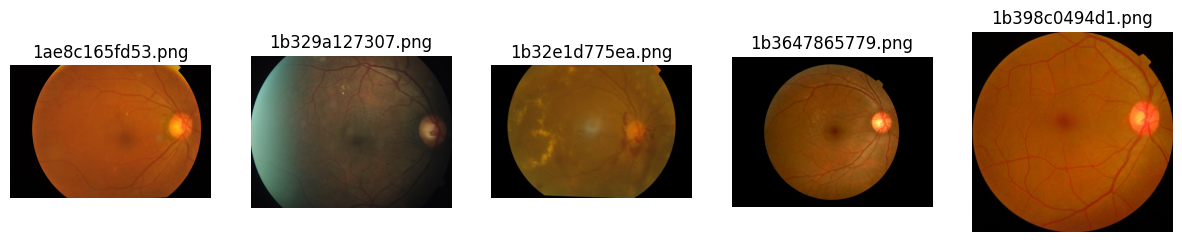

In [10]:
# Afiseaza niste imagini din aptos_normal
def display_sample_images(folder, num_images=5):

    # Print working directory
    print(f"Current working directory: {os.getcwd()}")

    import matplotlib.pyplot as plt
    images = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    sample_images = images[:num_images]
    
    plt.figure(figsize=(15, 5))
    for i, img_name in enumerate(sample_images):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, num_images, i+1)
        plt.imshow(img_rgb)
        plt.title(img_name)
        plt.axis('off')
    plt.show()

display_sample_images(os.path.join(INPUT_DIR, "train_images"), num_images=5)

In [11]:
# Subfoldere și fișiere CSV care trebuie mutate
FOLDERS = ["train_images", "val_images", "test_images"]
CSV_FILES = ["train_1.csv", "valid.csv", "test.csv"]

def crop_image_from_gray(img, tol=7):
    """
    Algoritmul standard folosit pe Kaggle pentru a decupa retina de fundalul negru.
    'tol' este toleranța pentru a considera un pixel ca fiind negru (7 este valoarea optimă).
    """
    # 1. Transformăm în alb-negru pentru a izola ușor zona luminoasă
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 2. Creăm o "mască" - găsim toți pixelii care au o valoare peste 7 (sunt destul de luminoși)
    mask = gray > tol
    
    # 3. Găsim coordonatele extreme (sus, jos, stânga, dreapta) ale zonei cu informație utilă
    coords = np.argwhere(mask)
    
    # Siguranță: Dacă poza e efectiv complet neagră din cauza unei erori la aparat, o lăsăm așa
    if coords.size == 0:
        return img
        
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    
    # 4. Decupăm imaginea originală exact pe baza acelui "dreptunghi" de selecție
    cropped = img[y0:y1, x0:x1]
    return cropped

def process_and_save_images():
    print(f"🚀 Începem procesarea datasetului. Destinație: {OUTPUT_DIR}\n")
    
    # 1. Creăm structura folderului de destinație
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    for folder in FOLDERS:
        os.makedirs(os.path.join(OUTPUT_DIR, folder), exist_ok=True)
        
    # 2. Copiem fișierele CSV
    print("📄 Copiem fișierele CSV...")
    for csv_file in CSV_FILES:
        src_csv = os.path.join(INPUT_DIR, csv_file)
        dst_csv = os.path.join(OUTPUT_DIR, csv_file)
        if os.path.exists(src_csv):
            shutil.copy2(src_csv, dst_csv)
            print(f"  ✓ {csv_file} a fost copiat.")
        else:
            print(f"  ⚠️ Atenție: {csv_file} nu a fost găsit în {INPUT_DIR}.")

    # 3. Procesăm imaginile pentru fiecare folder
    print("\n✂️ Începem decuparea imaginilor (Cropping)...")
    for folder in FOLDERS:
        src_folder = os.path.join(INPUT_DIR, folder)
        dst_folder = os.path.join(OUTPUT_DIR, folder)
        
        if not os.path.exists(src_folder):
            print(f"⚠️ Folderul {src_folder} nu există. Sărim peste el.")
            continue
            
        images = [f for f in os.listdir(src_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if not images:
            continue
            
        print(f"\nProcesăm [{folder}]: {len(images)} imagini")
        
        for img_name in tqdm(images, desc=folder):
            src_img_path = os.path.join(src_folder, img_name)
            dst_img_path = os.path.join(dst_folder, img_name)
            
            # A. Citim imaginea
            img = cv2.imread(src_img_path)
            if img is None:
                continue
                
            # B. Aplicăm algoritmul de crop
            img_cropped = crop_image_from_gray(img, tol=7)
            
            # C. Redimensionăm la un format pătrat uniform
            img_resized = cv2.resize(img_cropped, (TARGET_SIZE, TARGET_SIZE))
            
            # D. Salvăm imaginea procesată în noul folder
            cv2.imwrite(dst_img_path, img_resized)

    print("\n✅ Procesare finalizată! Noul dataset este gata în folderul:", OUTPUT_DIR)

if __name__ == "__main__":
    process_and_save_images()

🚀 Începem procesarea datasetului. Destinație: ../datasets/aptos_augmented_cropped

📄 Copiem fișierele CSV...
  ✓ train_1.csv a fost copiat.
  ✓ valid.csv a fost copiat.
  ✓ test.csv a fost copiat.

✂️ Începem decuparea imaginilor (Cropping)...

Procesăm [train_images]: 2930 imagini


train_images: 100%|██████████| 2930/2930 [05:32<00:00,  8.82it/s]



Procesăm [val_images]: 366 imagini


val_images: 100%|██████████| 366/366 [00:44<00:00,  8.22it/s]



Procesăm [test_images]: 366 imagini


test_images: 100%|██████████| 366/366 [00:39<00:00,  9.19it/s]


✅ Procesare finalizată! Noul dataset este gata în folderul: ../datasets/aptos_augmented_cropped
